# Phase 1: Data Acquisition & Understanding
- ข้อมูลหลักของเราจะอยู่ที่ไฟล์ `loan_portfolio.csv` ซึ่งเป็นข้อมูลสินเชื่อ


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูลหลัก
df_loan = pd.read_csv('data/loan_portfolio.csv')

# ดูขนาดของข้อมูล (จำนวนแถว, จำนวนคอลัมน์)
print(f"ขนาดของข้อมูล: {df_loan.shape}")

# ดูตัวอย่างข้อมูล 5 แถวแรก
df_loan.head()


ขนาดของข้อมูล: (50000, 24)


,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,default_date,survival_months,recovery_rate,loss_given_default
0,L000001,2017-10-01,2019-10-01,24,Technology,mortgage,secured,B,704,1035611.99,...,0.041076,0.7858,33426.80,161508.03,442905.14,0,NaN,24,NaN,NaN
1,L000002,2016-06-01,2020-06-01,48,Healthcare,term_loan,unsecured,A,702,800786.92,...,0.000887,0.7034,499.82,16771.62,6622.66,0,NaN,48,NaN,NaN
2,L000003,2023-08-01,2024-12-31,36,Real_Estate,bond,secured,BBB,699,4327864.12,...,0.002622,0.5503,6243.54,121781.72,82726.94,0,NaN,36,NaN,NaN
3,L000004,2016-04-01,2024-12-31,120,Real_Estate,term_loan,secured,B,641,3810461.19,...,0.041679,0.3541,56237.33,269661.85,745144.64,0,NaN,120,NaN,NaN
4,L000005,2015-10-01,2019-10-01,48,Energy,bond,unsecured,CCC,597,2925538.53,...,0.136071,0.6576,261778.69,659614.05,3468567.58,0,NaN,48,NaN,NaN


In [21]:
# ดูชนิดของข้อมูล (Data Types) และตรวจสอบค่าว่าง (Missing Values)
df_loan.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             50000 non-null  object 
 1   origination_date    50000 non-null  object 
 2   maturity_date       50000 non-null  object 
 3   maturity_months     50000 non-null  int64  
 4   sector              50000 non-null  object 
 5   loan_type           50000 non-null  object 
 6   collateral          50000 non-null  object 
 7   initial_rating      50000 non-null  object 
 8   credit_score        50000 non-null  int64  
 9   ead                 50000 non-null  float64
 10  coupon_rate         50000 non-null  float64
 11  leverage            50000 non-null  float64
 12  interest_coverage   50000 non-null  float64
 13  debt_to_equity      50000 non-null  float64
 14  pd_annual           50000 non-null  float64
 15  lgd                 50000 non-null  float64
 16  el  

In [ ]:
# check columns
df_loan.columns

Index(['loan_id', 'origination_date', 'maturity_date', 'maturity_months',
       'sector', 'loan_type', 'collateral', 'initial_rating', 'credit_score',
       'ead', 'coupon_rate', 'leverage', 'interest_coverage', 'debt_to_equity',
       'pd_annual', 'lgd', 'el', 'unexpected_loss', 'rwa', 'defaulted',
       'default_date', 'survival_months', 'recovery_rate',
       'loss_given_default'],
      dtype='object')

In [23]:
# descriptive stat
df_loan.describe()


,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,survival_months,recovery_rate,loss_given_default
count,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,50000.00000,50000.000000,6950.000000,6.950000e+03
mean,53.970480,714.982560,3.298605e+06,3.079087,6.913779,3.764089,2.090884,0.022461,0.546516,3.847572e+04,1.815605e+05,5.098033e+05,0.13900,49.124620,0.454562,1.713657e+06
std,26.716251,50.893411,6.661943e+06,1.103558,3.686415,2.014019,1.570126,0.040437,0.144332,1.590801e+05,4.966954e+05,2.107811e+06,0.34595,26.903824,0.145548,3.612190e+06
min,12.000000,518.000000,5.000000e+04,1.000000,0.500000,0.500000,0.100000,0.000158,0.091800,3.600000e+00,2.735300e+02,4.765000e+01,0.00000,1.000000,0.020000,1.433000e+04
25%,36.000000,679.000000,5.482685e+05,2.357000,4.060000,2.370000,1.030000,0.001229,0.442800,7.875300e+02,1.720746e+04,1.043481e+04,0.00000,36.000000,0.352900,2.915719e+05
50%,48.000000,715.000000,1.389712e+06,3.063500,6.080000,3.310000,1.650000,0.002788,0.544800,3.587830e+03,5.205993e+04,4.753875e+04,0.00000,48.000000,0.456100,7.198182e+05
75%,60.000000,750.000000,3.425439e+06,3.735000,9.070000,4.650000,2.640000,0.015868,0.646725,1.856052e+04,1.559430e+05,2.459269e+05,0.00000,60.000000,0.560275,1.750272e+06
max,120.000000,850.000000,3.611778e+08,7.531000,15.000000,20.000000,10.000000,0.242523,0.980000,6.411410e+06,2.239212e+07,8.495118e+07,1.00000,120.000000,0.857800,1.113264e+08


#### Remove the columns 
- Data Leakage (post-default) : 'default_date', 'survival_months', 'recovery_rate', 'loss_given_default', 'lgd'
- Output Metrics 
* 'pd_annual' (ความน่าจะเป็นที่จะเบี้ยวหนี้รายปี - Predicted)
* 'el' (Expected Loss - ความเสียหายที่คาดว่าจะเกิด)
* 'unexpected_loss'
* 'rwa' (Risk-Weighted Assets)
* 'loan_id' 

In [24]:
# list of remove columns
columns_to_drop = [
    'default_date', 'survival_months', 'recovery_rate', 
    'loss_given_default', 'lgd', 'pd_annual', 
    'el', 'unexpected_loss', 'rwa', 'loan_id'
]

# ทำการลบ
df_loan_clean = df_loan.drop(columns=columns_to_drop)

# เช็คดูว่าเหลือคอลัมน์กี่ตัว
print(f"จำนวนคอลัมน์ที่เหลือสำหรับสอนโมเดล: {df_loan_clean.shape[1]} คอลัมน์")
df_loan_clean.columns

จำนวนคอลัมน์ที่เหลือสำหรับสอนโมเดล: 14 คอลัมน์


Index(['origination_date', 'maturity_date', 'maturity_months', 'sector',
       'loan_type', 'collateral', 'initial_rating', 'credit_score', 'ead',
       'coupon_rate', 'leverage', 'interest_coverage', 'debt_to_equity',
       'defaulted'],
      dtype='object')

In [ ]:
## calculate the portion of defaulted per dataset 
df_loan_clean['defaulted'].value_counts(normalize=True) * 100

defaulted
0    86.1
1    13.9
Name: proportion, dtype: float64

# Phase 2: Exploratory Data Analysis (EDA) 📊

/var/folders/59/twp_h7qd10x5kg1x7wqlmw940000gn/T/ipykernel_14231/1326561583.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_loan_clean, x='sector', y='defaulted', errorbar=None, palette='viridis')


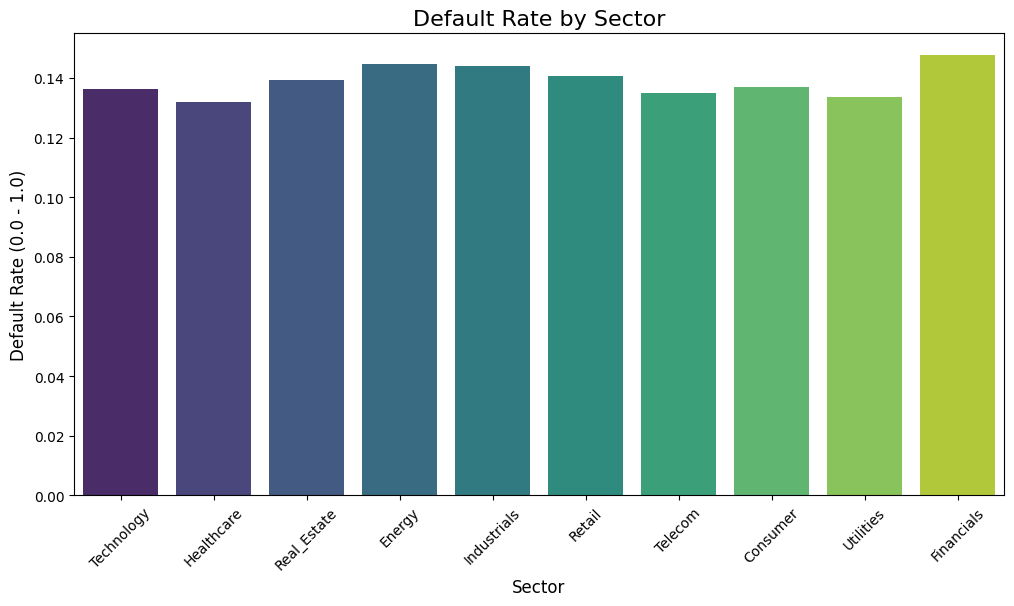

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# ตั้งค่าขนาดกราฟ
plt.figure(figsize=(12, 6))

# วาดกราฟแท่ง (Bar plot) ดูอัตราการเบี้ยวหนี้ แยกตามอุตสาหกรรม (sector)
# ci=None คือไม่เอาเส้น error bar จะได้ดูสะอาดๆ
sns.barplot(data=df_loan_clean, x='sector', y='defaulted', errorbar=None, palette='viridis')

plt.title('Default Rate by Sector', fontsize=16)
plt.ylabel('Default Rate (0.0 - 1.0)', fontsize=12)
plt.xlabel('Sector', fontsize=12)

# หมุนแกน x ให้ชื่ออุตสาหกรรมไม่ทับกัน
plt.xticks(rotation=45)
plt.show()

# Phase 3: Feature Engineering (Data Preprocessing)

- we will use One-Hot Encoding for create column with binary value 

In [27]:
# 1. ดูว่าคอลัมน์ไหนบ้างที่เป็นตัวหนังสือ (object)
categorical_cols = df_loan_clean.select_dtypes(include=['object']).columns
print(f"คอลัมน์ที่เป็นตัวหนังสือ: {list(categorical_cols)}")

# 2. ทำ One-Hot Encoding แปลงตัวหนังสือเป็น 0 กับ 1
df_encoded = pd.get_dummies(df_loan_clean, columns=categorical_cols, drop_first=True)

# แปลงค่า True/False จากการทำ Dummies ให้เป็น 1/0
df_encoded = df_encoded.astype(float)

# 3. ลองดูหน้าตาข้อมูลใหม่
print(f"\nจำนวนคอลัมน์หลังแปลงข้อมูล: {df_encoded.shape[1]} คอลัมน์")
df_encoded.head()

คอลัมน์ที่เป็นตัวหนังสือ: ['origination_date', 'maturity_date', 'sector', 'loan_type', 'collateral', 'initial_rating']

จำนวนคอลัมน์หลังแปลงข้อมูล: 244 คอลัมน์


,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,defaulted,origination_date_2015-02-01,origination_date_2015-03-01,...,loan_type_revolving,loan_type_term_loan,collateral_secured,collateral_unsecured,initial_rating_AA,initial_rating_AAA,initial_rating_B,initial_rating_BB,initial_rating_BBB,initial_rating_CCC
0,24.0,704.0,1035611.99,3.776,6.54,3.47,1.40,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,48.0,702.0,800786.92,3.895,12.26,4.47,2.77,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,36.0,699.0,4327864.12,4.365,8.98,6.02,2.18,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,120.0,641.0,3810461.19,3.749,13.12,5.93,1.75,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,48.0,597.0,2925538.53,5.231,1.80,4.39,1.79,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


- Scaling (Standardization)

In [28]:
from sklearn.preprocessing import StandardScaler

# แยก X (ตัวแปรต้น) และ y (เป้าหมายคือ defaulted)
X = df_encoded.drop(columns=['defaulted'])
y = df_encoded['defaulted']

# ปรับสเกล X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("ปรับสเกลเรียบร้อย! พร้อมป้อนเข้าโมเดลแล้วครับ 🤖")

ปรับสเกลเรียบร้อย! พร้อมป้อนเข้าโมเดลแล้วครับ 🤖


# Phase 4: Data Model 

- 1. Split data (Train/Test Split)
- 2. Select Model (Algorithm): For Default we use Logistic Regression Model
- 3. Evaluate the Model : with metrics 

จำนวนข้อมูลสำหรับสอนโมเดล: 40000 แถว
จำนวนข้อมูลสำหรับทดสอบ: 10000 แถว

--- รายงานความแม่นยำ (Classification Report) ---
              precision    recall  f1-score   support

         0.0       0.93      0.74      0.83      8610
         1.0       0.30      0.68      0.41      1390

    accuracy                           0.73     10000
   macro avg       0.62      0.71      0.62     10000
weighted avg       0.85      0.73      0.77     10000

ROC-AUC Score: 0.8077


/Users/fhyfhy/Desktop/DA/credit_risk_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/fhyfhy/Desktop/DA/credit_risk_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/fhyfhy/Desktop/DA/credit_risk_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/fhyfhy/Desktop/DA/credit_risk_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/fhyfhy/Desktop/DA/credit_risk_project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:

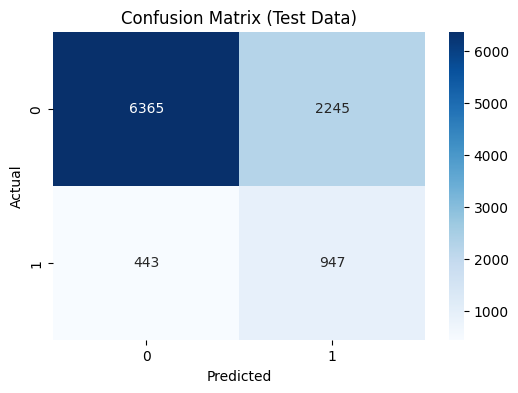

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. แบ่งข้อมูล (Train 80% / Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"จำนวนข้อมูลสำหรับสอนโมเดล: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูลสำหรับทดสอบ: {X_test.shape[0]} แถว\n")

# 2. สร้างและสอนโมเดล Logistic Regression
# ใช้ class_weight='balanced' เพราะคนเบี้ยวหนี้มีแค่ 13% โมเดลจะได้ให้ความสำคัญกับคนกลุ่มนี้เพิ่มขึ้น
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# 3. ให้โมเดลทำนายข้อสอบ (Test set)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # ความน่าจะเป็นที่จะเบี้ยวหนี้

# 4. วัดผลลัพธ์
print("--- รายงานความแม่นยำ (Classification Report) ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 5. วาดตาราง Confusion Matrix สวยๆ
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Data)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Phase 5 - Prepare for Exporting to Dashboard 

In [31]:
# 1. สร้างตารางจัดอันดับความสำคัญของแต่ละปัจจัย (Feature Importance)
feature_names = X.columns
coefficients = model.coef_[0]

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Impact': coefficients
})

# เรียงลำดับจากปัจจัยที่ส่งผลให้เบี้ยวหนี้มากที่สุด (ค่า Impact เป็นบวกเยอะๆ)
df_importance = df_importance.sort_values(by='Impact', ascending=False)

# 2. Export เป็นไฟล์ CSV (เซฟไว้ในโฟลเดอร์ data)
df_importance.to_csv('data/feature_importance.csv', index=False)

print("Export ไฟล์ 'feature_importance.csv' สำเร็จแล้ว! 🎉")

# ลองดู Top 5 ปัจจัยที่ทำให้คนเบี้ยวหนี้
print("\n--- Top 5 ปัจจัยที่ทำให้คนเบี้ยวหนี้ ---")
print(df_importance.head(5))

Export ไฟล์ 'feature_importance.csv' สำเร็จแล้ว! 🎉

--- Top 5 ปัจจัยที่ทำให้คนเบี้ยวหนี้ ---
                      Feature    Impact
242        initial_rating_CCC  0.965113
239          initial_rating_B  0.615921
0             maturity_months  0.405244
240         initial_rating_BB  0.268655
221  maturity_date_2024-12-31  0.158497


## Adapt Mode 

In [32]:
# 1. ดึง Index (หมายเลขแถว) จากข้อสอบ (y_test) มาเพื่อใช้หาตัวลูกค้า
test_indices = y_test.index

# 2. ดึงข้อมูลดั้งเดิมของลูกค้ากลุ่มนี้มาจาก df_loan (ตัวที่เราโหลดมาตอนแรกสุด)
# เลือกมาเฉพาะคอลัมน์ที่ผู้บริหารน่าจะอยากเห็น
df_actionable = df_loan.loc[test_indices, ['loan_id', 'sector', 'initial_rating', 'ead']].copy()

# 3. เติมคอลัมน์ผลลัพธ์จากโมเดลของเราเข้าไป
df_actionable['Actual_Default'] = y_test.values # ความจริง
df_actionable['Predicted_Default'] = y_pred # สิ่งที่โมเดลทาย (0 หรือ 1)
df_actionable['Risk_Score_Percent'] = (y_prob * 100).round(2) # โอกาสเบี้ยวหนี้ (%)

# 4. เรียงลำดับจากคนที่ "มีความเสี่ยงสูงสุด" ไปหาต่ำสุด
df_actionable = df_actionable.sort_values(by='Risk_Score_Percent', ascending=False)

# 5. Export ไปทำ Dashboard ข้อ 4 
df_actionable.to_csv('data/high_risk_loans_dashboard.csv', index=False)

print("Export ไฟล์ 'high_risk_loans_dashboard.csv' สำหรับทำตารางเรียบร้อยแล้ว!")
df_actionable.head(10) # ดูตัวอย่าง 10 อันดับแรกที่เสี่ยงสุดๆ

Export ไฟล์ 'high_risk_loans_dashboard.csv' สำหรับทำตารางเรียบร้อยแล้ว!


,loan_id,sector,initial_rating,ead,Actual_Default,Predicted_Default,Risk_Score_Percent
28220,L028221,Real_Estate,CCC,4947334.75,1.0,1.0,98.67
35133,L035134,Telecom,CCC,24024763.61,1.0,1.0,98.62
783,L000784,Real_Estate,CCC,6038637.31,0.0,1.0,98.54
4182,L004183,Real_Estate,CCC,4986469.40,0.0,1.0,98.45
49398,L049399,Healthcare,CCC,160524.22,1.0,1.0,98.43
46367,L046368,Financials,CCC,2419797.31,1.0,1.0,98.38
19381,L019382,Energy,CCC,1150489.54,1.0,1.0,98.16
31736,L031737,Healthcare,CCC,567023.41,1.0,1.0,98.09
44445,L044446,Telecom,CCC,6369948.53,1.0,1.0,98.08
4809,L004810,Technology,CCC,1024338.54,1.0,1.0,98.03
